# Time evolution of $\mathrm{Yb}$ spin-orbit coupled system with 2-body loss

- Units
    - $\hbar=1.0545\times 10^{-34} \,\mathrm{J}\cdot\mathrm{s}$
    - $E_r/\hbar = 8.8593 \,\mathrm{kHz}$
    - $k_r = \sin\left(\frac{\theta}{2}\right)\frac{2\pi}{556 \,\mathrm{nm}} = 6.9462\times10^6 \, \mathrm{m}^{-1}$

Where $\theta=75.854^\circ$
  
- Derived Units
    - $t_r = \hbar/E_r = 0.1129 \,\mathrm{ms}$
    - $m_r = \hbar^2 k_r^2 / 2 E_r = m_{\mathrm{Yb}} = 2.872×10^{-25} \, \mathrm{kg}$

- Hamiltonian
  
$$
\begin{equation}
    H=\sum_{\mathbf{k}}
    \begin{pmatrix}
        c_{\uparrow}^\dagger(\mathbf{k}) & c_{\downarrow}^\dagger(\mathbf{k})
    \end{pmatrix}
    \begin{pmatrix}
        \frac{\hbar^2(q_x-k_r)^2}{2m_{\mathrm{Yb}}} + \frac{\delta}{2} & \frac{\Omega_R}{2} \\
        \frac{\Omega_R}{2} & \frac{\hbar^2(q_x+k_r)^2}{2m_{\mathrm{Yb}}}-\frac{\delta}{2}
    \end{pmatrix}
    \begin{pmatrix}
        c_{\uparrow}(\mathbf{k}) \\
        c_{\downarrow}(\mathbf{k})
    \end{pmatrix}
    -\frac{1}{N}\frac{i}{2}\gamma\sum_{\mathbf{k}, \mathbf{k}', \mathbf{q}}c_\downarrow^\dagger(\mathbf{k}'+\mathbf{q})c_\uparrow^\dagger(\mathbf{k}-\mathbf{q})c_\uparrow(\mathbf{k})c_\downarrow(\mathbf{k}')
\end{equation}
$$

$q_x=[-2.5 k_r, ..., -0.5 k_r, 0, 0.5 k_r, k_r, ..., 3 k_r]$ for $L=12$

- parameters
  - $\hbar/\hbar = 1$
  - $k_r/k_r = 1$
  - $m_{\mathrm{Yb}}/m_r = 1$
  - $\delta/E_r = 4$
  - $\Omega_R/E_r = 3.5$
  - $\gamma/E_r \sim 0.2$


- basis
  
$$\mathcal{B}= \{c_{\sigma_1}^\dagger(\mathbf{k}_1)c_{\sigma_2}^\dagger(\mathbf{k}_2)\cdots c_{\sigma_n}^\dagger(\mathbf{k}_n)\ket{0}:\sigma_j=\uparrow,\downarrow, i_{\mathbf{k}_1}<i_{\mathbf{k}_2}<\cdots<i_{\mathbf{k}_n}\}$$
$$[H]_{\mathcal{B}}$$

In [ ]:
!pip install diffrax

: 

In [ ]:
!unzip opalg

In [2]:
import os
import time
import itertools
import functools
import operator
import pickle
from pprint import pprint

import jax
jax.config.update("jax_enable_x64", True)
jax.config.update('jax_platform_name', 'cpu')
import jax.numpy as jnp


import numpy as np
import tqdm
import matplotlib.pyplot as plt

import diffrax as dfx

from ybsoc import *

## System Definition

In [22]:
L = 12
N = 4

hbar = 1.

m_Yb = 1.

# q = 1.
# delta = 1.5486
# omega_R = 1.0585

k = 0.
delta = 0.
omega_R = 0.

gamma = 0.1
d = 2 * (2 * jnp.pi) / L

system = YbSOC2bodyLoss(
    d=d,
    lengths=[L,],
    n_particle=N,
    hbar=hbar,
    q=k,
    m_Yb=m_Yb,
    delta=delta,
    omega_R=omega_R,
    gamma=gamma,
    array_type='numpy'
)

hamiltonian = system.dense_hamiltonian(
    display_progress=True
)

100%|██████████| 10626/10626 [00:01<00:00, 7018.79it/s]


In [29]:
import netket as nk
from netket.operator import FermionOperator2ndJax
from netket.operator.fermion import destroy as c
from netket.operator.fermion import create as cdag
from netket.operator.fermion import number as nc

from opalg.lattice import *

lengths = [L,]

hi = nk.hilbert.SpinOrbitalFermions(
    lengths[0],
    s=1/2,
    n_fermions=N
)

H = FermionOperator2ndJax(hi, dtype=jnp.complex128)

sites = multi_indices(lengths)
multi_to_flatten = multi_to_flat_index_map(lengths)

momentums = momentum_arr(lengths, d)

n_sites = len(sites)

# kinetic energy terms
for idx in range(len(sites)):
    c_up = c(hi, idx, 1)
    c_down = c(hi, idx, -1)
    cdag_up = cdag(hi, idx, 1)
    cdag_down = cdag(hi, idx, -1)
    
    q = momentums[idx].item()
    diag_up = (hbar ** 2) * ((q - k) ** 2) / (2 * m_Yb) + delta / 2
    diag_down = (hbar ** 2) * ((q + k) ** 2) / (2 * m_Yb) - delta / 2
    off_diagonal = omega_R / 2
    
    H += diag_up * cdag_up * c_up
    H += diag_down * cdag_down * c_down
    H += off_diagonal * (cdag_up * c_down + cdag_down * c_up)

# interaction terms
for k1_idx, k2_idx, q_idx in itertools.product(
        range(len(sites)), repeat=3
):
    k1_midx = sites[k1_idx]
    k2_midx = sites[k2_idx]
    q_midx = sites[q_idx]
    k1_idx_f = multi_to_flatten[subtract_multi_indices(k1_midx, q_midx, lengths)]
    k2_idx_f = multi_to_flatten[add_multi_indices(k2_midx, q_midx, lengths)]
    
    c1 = cdag(hi, k2_idx_f, -1)
    c2 = cdag(hi, k1_idx_f, 1)
    c3 = c(hi, k1_idx, 1)
    c4 = c(hi, k2_idx, -1)
    
    H += (-(1 / n_sites) * (1j / 2) * gamma) * c1 * c2 * c3 * c4

In [24]:
hamiltonian_nk = H.to_dense()

In [25]:
eigenvalues_nk, eigenvectors_nk = np.linalg.eig(hamiltonian_nk)

In [26]:
eigenvalues_sorted = np.sort(eigenvalues)
eigenvalues_nk_sorted = np.sort(eigenvalues_nk)

In [ ]:
hi.local_indices_to_states

## Initial State Preparation

In [ ]:
pure = system.get_momentum_eigenstate(
    (
        ((0,), 1),
        ((1,), 1),
        ((2,), 1),
        ((11,), 1),
    )
)

mixture = system.get_momentum_eigenstate(
    (
        ((0,), 1),
        ((1,), -1),
        ((2,), 1),
        ((11,), -1),
    )
)

prob_up = 2/3
theta = 2 * np.arccos(np.sqrt(prob_up))  # p(up) = 2/3, p(down) = 1/3
phi = 0
c = (np.cos(theta / 2), np.exp(1j * phi) * np.sin(theta / 2))

superposition = np.zeros_like(mixture)
for c1, c2, c3, c4 in itertools.product([0, 1], repeat=4):
    amp = c[c1] * c[c2] * c[c3] * c[c4]
    basis = system.get_momentum_eigenstate(
        (
            ((0,), 2 * c1 - 1),
            ((1,), 2 * c2 - 1),
            ((2,), 2 * c3 - 1),
            ((3,), 2 * c4 - 1),
        )
    )
    superposition = superposition + amp * basis

## Simulation by exact propagator

In [30]:
jnp.linalg.norm(superposition)

Array(1., dtype=float64)

In [15]:
superposition[superposition.nonzero()]

array([0.11111129+0.j, 0.157135  +0.j, 0.157135  +0.j, 0.22222231+0.j,
       0.157135  +0.j, 0.22222231+0.j, 0.22222231+0.j, 0.31426962+0.j,
       0.157135  +0.j, 0.22222231+0.j, 0.22222231+0.j, 0.31426962+0.j,
       0.22222231+0.j, 0.31426962+0.j, 0.31426962+0.j, 0.44444408+0.j])

In [17]:
jnp.array([c[0] * c[0] * c[0] * c[0], c[0] * c[0] * c[0] * c[1], c[0] * c[0] * c[1] * c[1], c[0] * c[1] * c[1] * c[1], c[1] * c[1] * c[1] * c[1]])

Array([0.44444408+0.j, 0.31426962+0.j, 0.22222231+0.j, 0.157135  +0.j,
       0.11111129+0.j], dtype=complex128)

In [18]:
jnp.einsum("i,ij,j", superposition.conj(), hamiltonian, superposition)

Array(1.75-0.01111112j, dtype=complex128)

In [5]:
eigenvalues, eigenvectors = np.linalg.eig(hamiltonian)

In [ ]:
# initial_state = pure
# initial_state = mixture
initial_state = superposition

psi_tilde = np.linalg.solve(eigenvectors, initial_state)

t0 = 0
t1 = 0.8 / 0.1129
save_at = np.linspace(t0, t1, 201)
step_size = save_at[1] - save_at[0]

evolution_operator_diag = np.exp(-1j * eigenvalues * step_size / system.hbar)
psis = np.zeros((len(save_at), len(psi_tilde)), dtype=np.complex128)

psis[0, :] = np.einsum('ij,j->i', eigenvectors, psi_tilde)
for i in tqdm.trange(len(save_at)):
    psis[i, :] = np.einsum('ij,j->i', eigenvectors, psi_tilde)
    psi_tilde = evolution_operator_diag * psi_tilde

spin_up_numbers, spin_down_numbers = system.momentum_sp_expected_numbers_vectorized(psis)

100%|██████████| 101/101 [00:19<00:00,  5.16it/s]


## ODE Integration

\begin{equation}
\frac{d\rho}{dt}=-\frac{i}{\hbar}\left[H\rho-\rho H^\dagger\right]-\operatorname{off-diagonal}(\rho)/T_2
\end{equation}

- $T_2 = 0.5 \,\mathrm{ms}$ 

In [21]:
hamiltonian_jarr = jnp.array(hamiltonian, dtype=jnp.complex128)
initial_rho = jnp.outer(superposition, superposition.conj())      # |ψ〉〈ψ|

def drhodt(t, rho, args):
    (lam,) = args
    vne_term = (-1j / hbar) * (jnp.matmul(hamiltonian_jarr, rho) - jnp.matmul(rho, hamiltonian_jarr.T.conj()))
    decoherence_term = -lam * (rho - jnp.diag(jnp.diag(rho)))
    return vne_term + decoherence_term

term = dfx.ODETerm(drhodt)
solver = dfx.Dopri8()
saveat = dfx.SaveAt(ts=save_at)
stepsize_controller = dfx.PIDController(atol=1e-5, rtol=1e-5)

T2 = 0.5 / 0.1129

sol = dfx.diffeqsolve(
    term, solver, t0, t1, 1e-2, initial_rho, (1/T2,),
    saveat=saveat, stepsize_controller=stepsize_controller, max_steps=4096
)

rhos = sol.ysd

C:\Users\pco0511\AppData\Roaming\Python\Python312\site-packages\equinox\_jit.py:55: UserWarning: Complex dtype support in Diffrax is a work in progress and may not yet produce correct results. Consider splitting your computation into real and imaginary parts instead.
  out = fun(*args, **kwargs)


MemoryError: bad allocation

In [10]:
num_op_diag = jnp.array(system.momentum_sp_num_op_diags())

def numper_expectation(rho):
    expected_numbers = jnp.einsum('ij,jj->i', num_op_diag, rho)
    up_total = jnp.sum(expected_numbers[0::2]).item().real
    down_total = jnp.sum(expected_numbers[1::2]).item().real
    return up_total, down_total

total_up_odeint = np.zeros((save_at.size,))
total_down_odeint = np.zeros((save_at.size,))

for i in range(save_at.size):
    total_up_odeint[i], total_down_odeint[i] = numper_expectation(rhos[i])

total_up_odeint /= system.n_particle
total_down_odeint /= system.n_particle

NameError: name 'rhos' is not defined

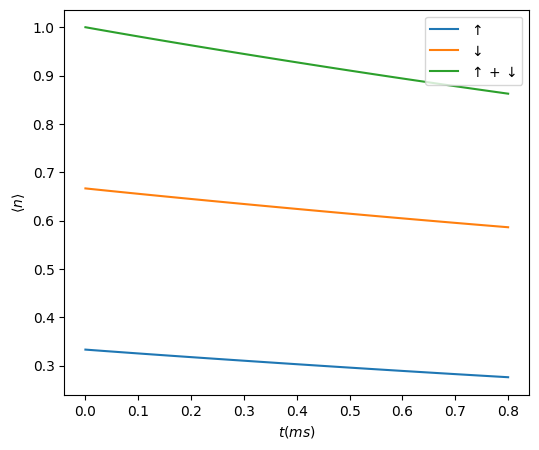

In [7]:
plt.figure(figsize=(6, 5))
t = save_at * 0.1129

# for i in range(8):
#     plt.plot(t, spin_up_numbers[:, i], label=f"$\\uparrow$, {i}")
#     plt.plot(t, spin_down_numbers[:, i], label=f"$\\downarrow$, {i}")

total_up = jnp.sum(spin_up_numbers, axis=1) / system.n_particle
total_down = jnp.sum(spin_down_numbers, axis=1) / system.n_particle

plt.plot(t, total_up, label="$\\uparrow$")
plt.plot(t, total_down, label="$\\downarrow$")
plt.plot(t, total_up + total_down, label="$\\uparrow + \\downarrow$")

plt.ylabel("$\\langle n \\rangle$")
plt.xlabel("$t (ms)$")

plt.legend()
plt.show()

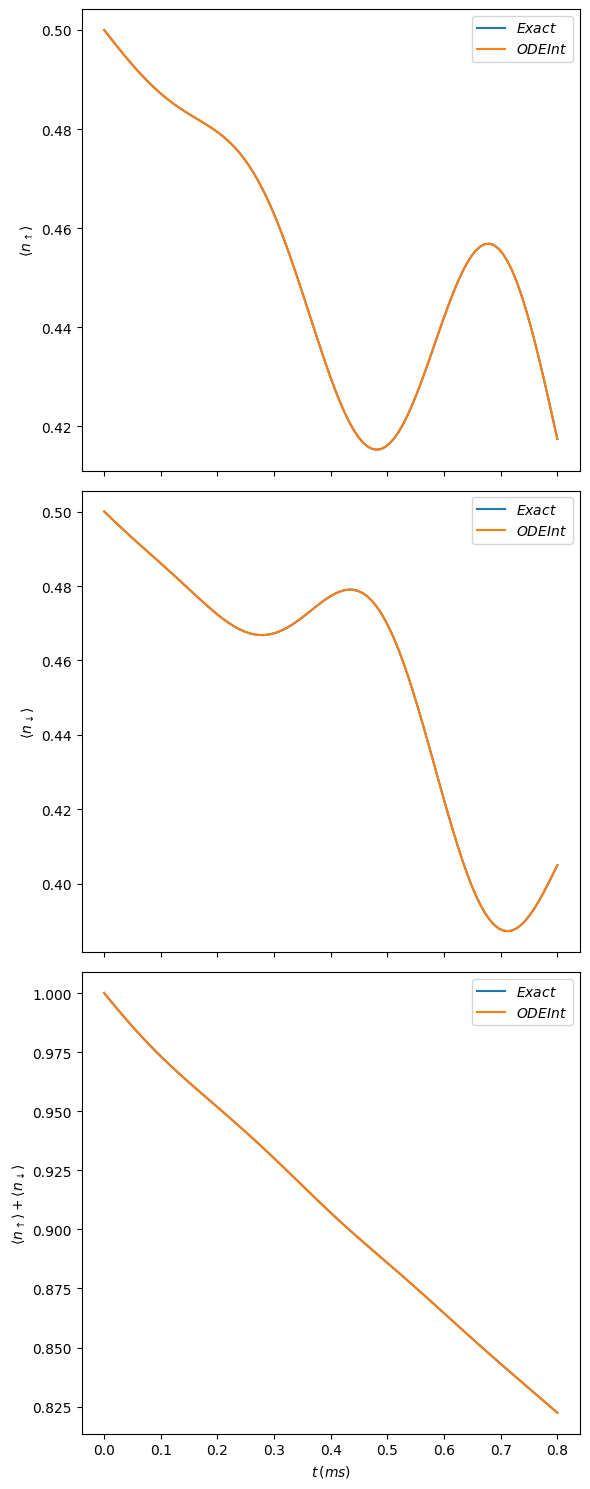

In [ ]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, sharex=True, figsize=(6, 15))

ax1.plot(t, total_up,   label="$Exact$")
ax1.plot(t, total_up_odeint, label="$ODEInt$")
ax1.set_ylabel("$\\langle n_{\\uparrow} \\rangle$")
ax1.legend()

ax2.plot(t, total_down,   label="$Exact$")
ax2.plot(t, total_down_odeint, label="$ODEInt$")
ax2.set_ylabel("$\\langle n_{\\downarrow} \\rangle$")
ax2.legend()


ax3.plot(t, total_up + total_down, label="$Exact$")
ax3.plot(t, total_up_odeint + total_down_odeint, label="$ODEInt$")
ax3.set_ylabel("$\\langle n_{\\uparrow} \\rangle + \\langle n_{\\downarrow} \\rangle$")
ax3.legend()
ax3.set_xlabel("$t\\,(ms)$")

plt.tight_layout()
plt.show()